In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv(
    r"C:\Users\Sriram\Downloads\diabetes_dataset_raw.csv"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:

df.head()

,Age,Sex,BMI,Blood_Pressure,S1_TC,S2_LDL,S3_HDL,S4_TCH,S5_LTG,S6_Glucose,Disease_Progression
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


In [4]:
df.tail()

,Age,Sex,BMI,Blood_Pressure,S1_TC,S2_LDL,S3_HDL,S4_TCH,S5_LTG,S6_Glucose,Disease_Progression
437,60.0,2.0,28.2,112.00,185.0,113.8,42.0,4.00,4.9836,93.0,178.0
438,47.0,2.0,24.9,75.00,225.0,166.0,42.0,5.00,4.4427,102.0,104.0
439,60.0,2.0,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0,132.0
440,36.0,1.0,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0,220.0
441,36.0,1.0,19.6,71.00,250.0,133.2,97.0,3.00,4.5951,92.0,57.0


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 442
Number of columns: 11


In [6]:
print("Columns in the dataset:")

for column in df.columns:
    print(column)

Columns in the dataset:
Age
Sex
BMI
Blood_Pressure
S1_TC
S2_LDL
S3_HDL
S4_TCH
S5_LTG
S6_Glucose
Disease_Progression


In [7]:
print(df.dtypes)

Age                    float64
Sex                    float64
BMI                    float64
Blood_Pressure         float64
S1_TC                  float64
S2_LDL                 float64
S3_HDL                 float64
S4_TCH                 float64
S5_LTG                 float64
S6_Glucose             float64
Disease_Progression    float64
dtype: object


In [8]:
missing = df.isnull().sum()

print("Missing values:")
print(missing)

Missing values:
Age                    0
Sex                    0
BMI                    0
Blood_Pressure         0
S1_TC                  0
S2_LDL                 0
S3_HDL                 0
S4_TCH                 0
S5_LTG                 0
S6_Glucose             0
Disease_Progression    0
dtype: int64


In [9]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,442.0,48.518100,13.109028,19.0000,38.2500,50.00000,59.0000,79.000
Sex,442.0,1.468326,0.499561,1.0000,1.0000,1.00000,2.0000,2.000
BMI,442.0,26.375792,4.418122,18.0000,23.2000,25.70000,29.2750,42.200
Blood_Pressure,442.0,94.647014,13.831283,62.0000,84.0000,93.00000,105.0000,133.000
S1_TC,442.0,189.140271,34.608052,97.0000,164.2500,186.00000,209.7500,301.000
S2_LDL,442.0,115.439140,30.413081,41.6000,96.0500,113.00000,134.5000,242.400
S3_HDL,442.0,49.788462,12.934202,22.0000,40.2500,48.00000,57.7500,99.000
S4_TCH,442.0,4.070249,1.290450,2.0000,3.0000,4.00000,5.0000,9.090
S5_LTG,442.0,4.641411,0.522391,3.2581,4.2767,4.62005,4.9972,6.107
S6_Glucose,442.0,91.260181,11.496335,58.0000,83.2500,91.00000,98.0000,124.000


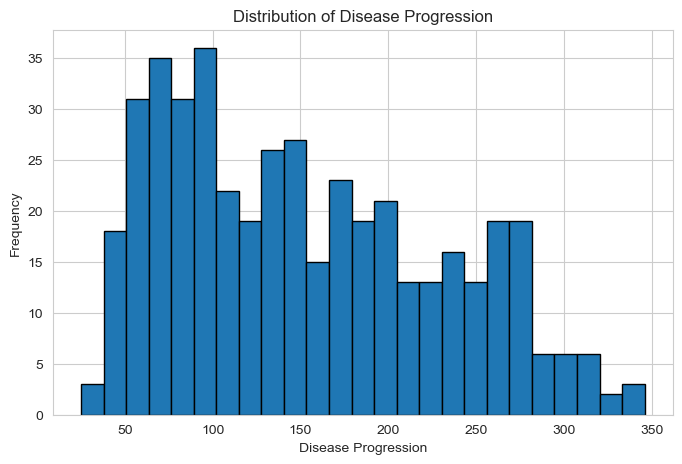

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Disease_Progression"],
    bins=25,
    edgecolor="black"
)

plt.title("Distribution of Disease Progression")
plt.xlabel("Disease Progression")
plt.ylabel("Frequency")

plt.show()

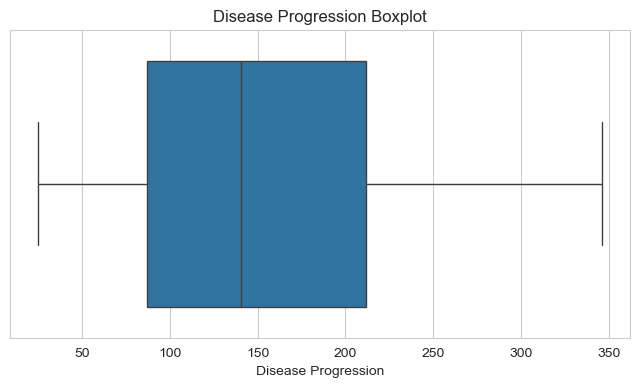

In [12]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["Disease_Progression"]
)

plt.title("Disease Progression Boxplot")
plt.xlabel("Disease Progression")

plt.show()

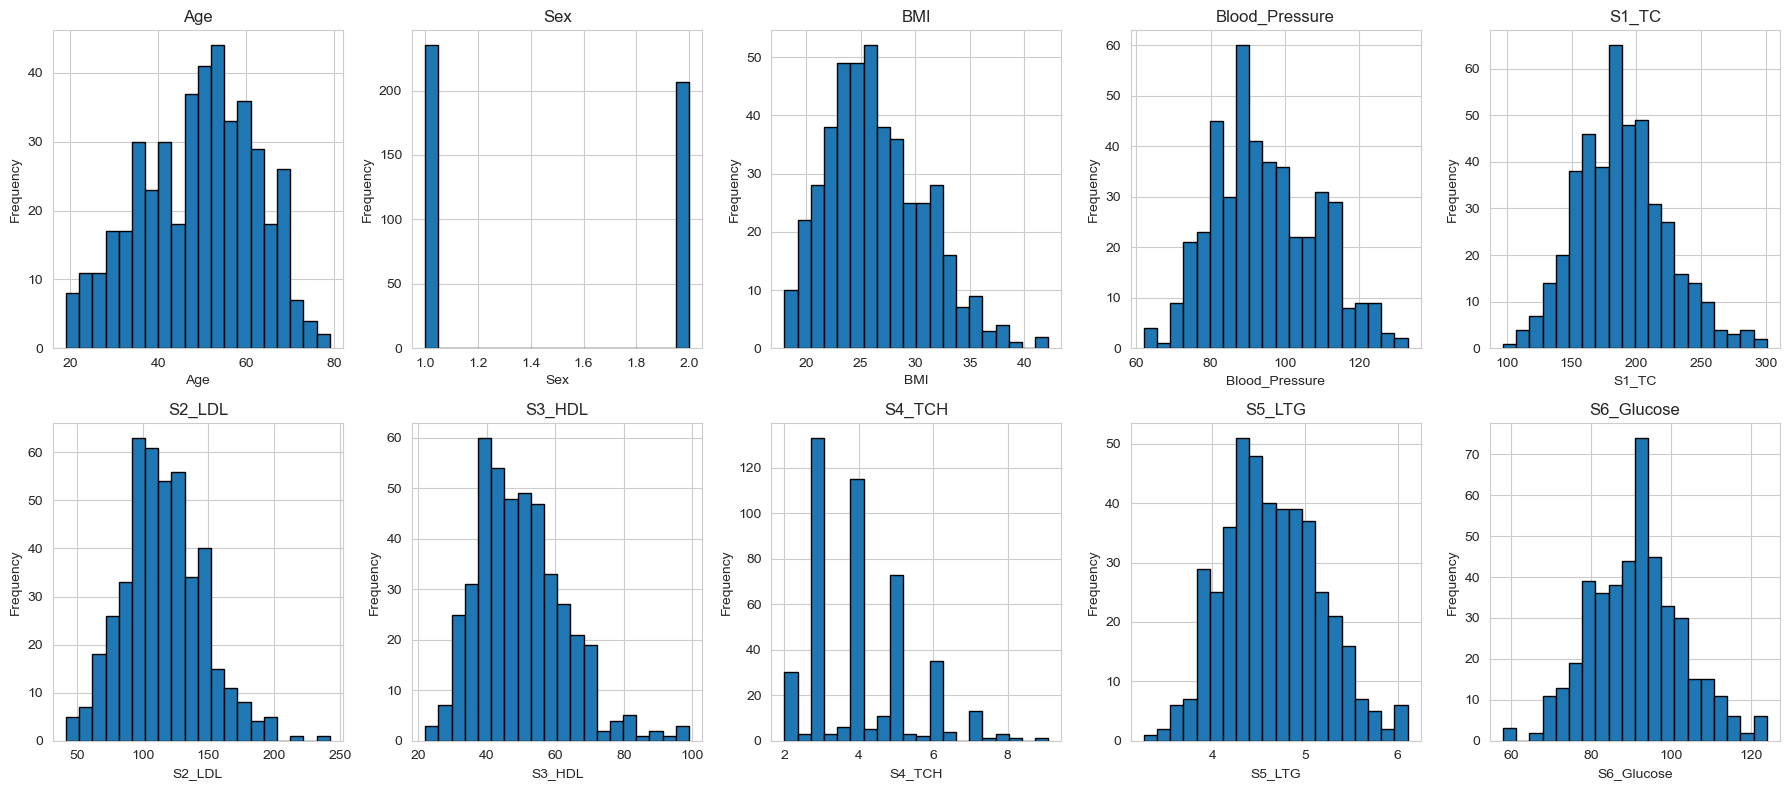

In [14]:
features = [
    "Age",
    "Sex",
    "BMI",
    "Blood_Pressure",
    "S1_TC",
    "S2_LDL",
    "S3_HDL",
    "S4_TCH",
    "S5_LTG",
    "S6_Glucose"
]

fig, axes = plt.subplots(
    2, 5,
    figsize=(18, 8)
)

for i, feature in enumerate(features):

    axes[i // 5, i % 5].hist(
        df[feature],
        bins=20,
        edgecolor="black"
    )

    axes[i // 5, i % 5].set_title(feature)
    axes[i // 5, i % 5].set_xlabel(feature)
    axes[i // 5, i % 5].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [15]:
correlation = df.corr()

correlation

,Age,Sex,BMI,Blood_Pressure,S1_TC,S2_LDL,S3_HDL,S4_TCH,S5_LTG,S6_Glucose,Disease_Progression
Age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
Sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
BMI,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
Blood_Pressure,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
S1_TC,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
S2_LDL,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
S3_HDL,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
S4_TCH,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
S5_LTG,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
S6_Glucose,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


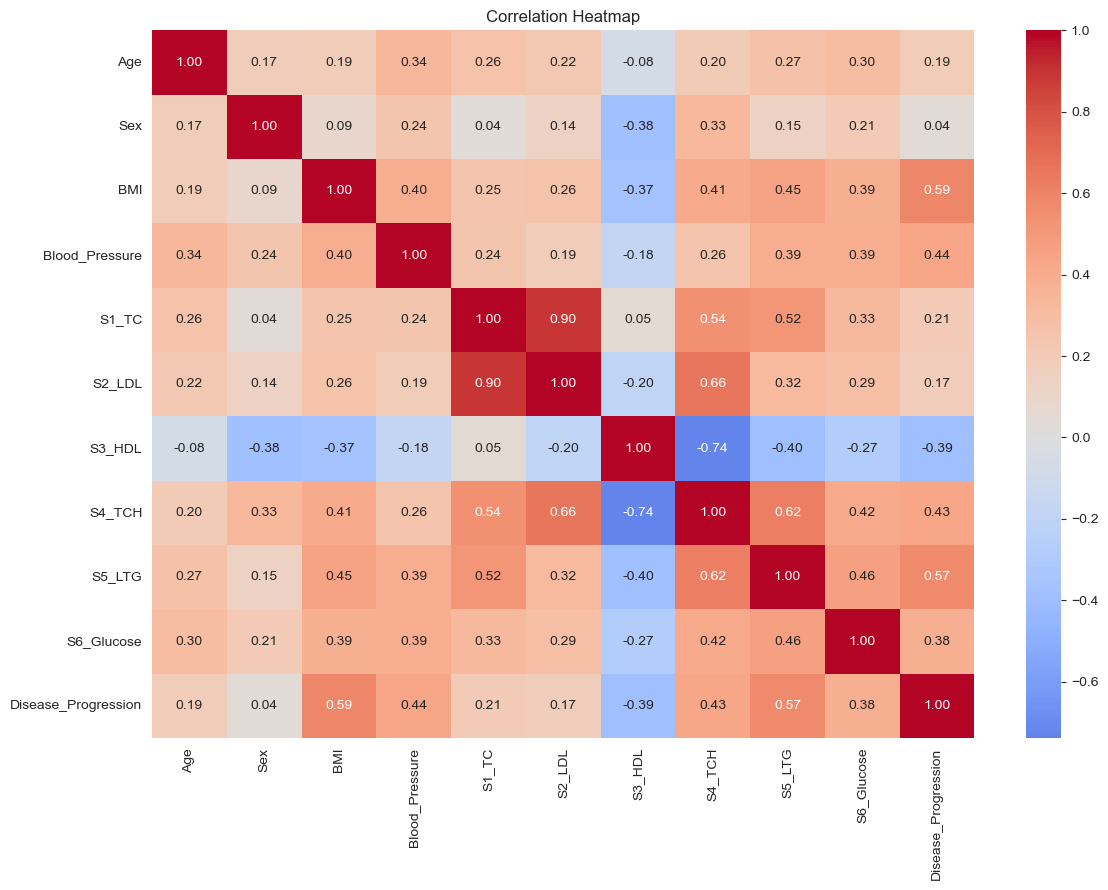

In [16]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [17]:
target_corr = correlation["Disease_Progression"]

target_corr = target_corr.drop(
    "Disease_Progression"
)

target_corr = target_corr.sort_values(
    ascending=False
)

print(target_corr)

BMI               0.586450
S5_LTG            0.565883
Blood_Pressure    0.441482
S4_TCH            0.430453
S6_Glucose        0.382483
S1_TC             0.212022
Age               0.187889
S2_LDL            0.174054
Sex               0.043062
S3_HDL           -0.394789
Name: Disease_Progression, dtype: float64


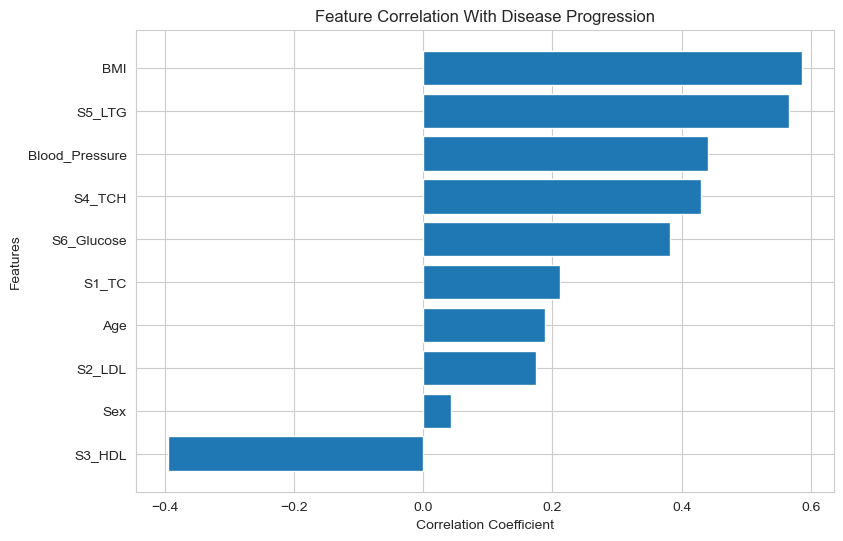

In [18]:
plt.figure(figsize=(9, 6))

plt.barh(
    target_corr.index,
    target_corr.values
)

plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.title(
    "Feature Correlation With Disease Progression"
)

plt.gca().invert_yaxis()

plt.show()

In [19]:
X = df.drop(
    "Disease_Progression",
    axis=1
)

y = df["Disease_Progression"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (442, 10)
y shape: (442,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (353, 10)
Testing data : (89, 10)


In [21]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Model training completed!")

Model training completed!


In [22]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [23]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R² Score:", round(r2, 4))

R² Score: 0.4526


In [24]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", round(mae, 4))

MAE: 42.7941


In [25]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("RMSE:", round(rmse, 4))

RMSE: 53.8534


In [26]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("RMSE:", round(rmse, 4))

RMSE: 53.8534


In [27]:
feature_coefficients = pd.Series(
    model.coef_,
    index=X.columns
)

print(feature_coefficients)

Age                0.137688
Sex              -23.064468
BMI                5.846363
Blood_Pressure     1.197093
S1_TC             -1.281685
S2_LDL             0.811152
S3_HDL             0.601653
S4_TCH            10.159539
S5_LTG            67.108962
S6_Glucose         0.201599
dtype: float64


In [28]:
feature_importance = (
    feature_coefficients
    .abs()
    .sort_values(
        ascending=False
    )
)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
S5_LTG            67.108962
Sex               23.064468
S4_TCH            10.159539
BMI                5.846363
S1_TC              1.281685
Blood_Pressure     1.197093
S2_LDL             0.811152
S3_HDL             0.601653
S6_Glucose         0.201599
Age                0.137688
dtype: float64


TOP 5 INFLUENTIAL FEATURES
S5_LTG    67.108962
Sex       23.064468
S4_TCH    10.159539
BMI        5.846363
S1_TC      1.281685
dtype: float64


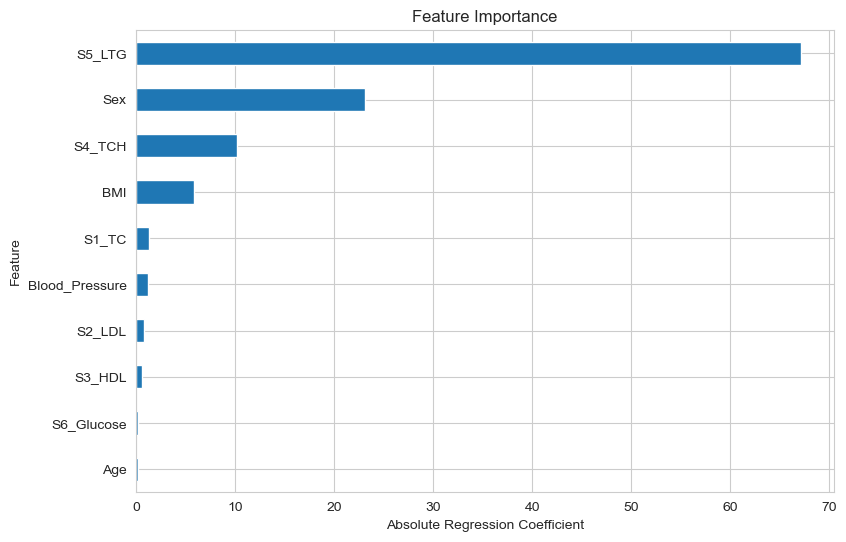

In [29]:
print("TOP 5 INFLUENTIAL FEATURES")
print("=" * 40)

print(
    feature_importance.head(5)
)
plt.figure(figsize=(9, 6))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.title(
    "Feature Importance"
)

plt.xlabel(
    "Absolute Regression Coefficient"
)

plt.ylabel("Feature")

plt.show()

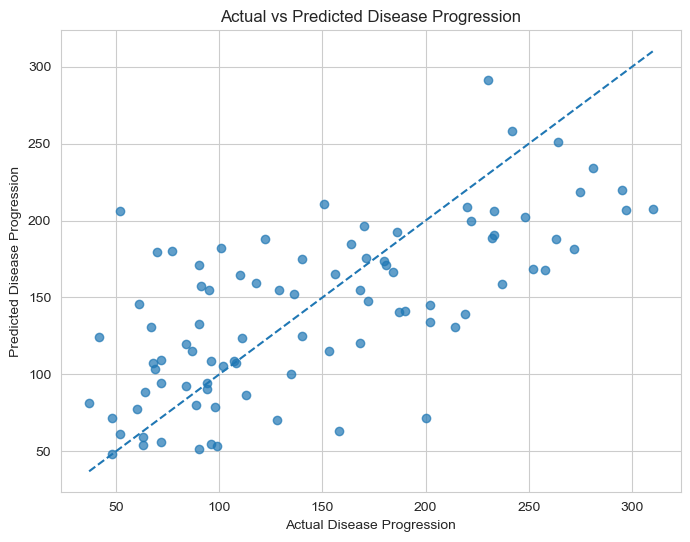

In [30]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(15)
comparison["Error"] = (
    comparison["Actual"]
    - comparison["Predicted"]
)

comparison.head(15)
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual Disease Progression"
)

plt.ylabel(
    "Predicted Disease Progression"
)

plt.title(
    "Actual vs Predicted Disease Progression"
)

plt.show()

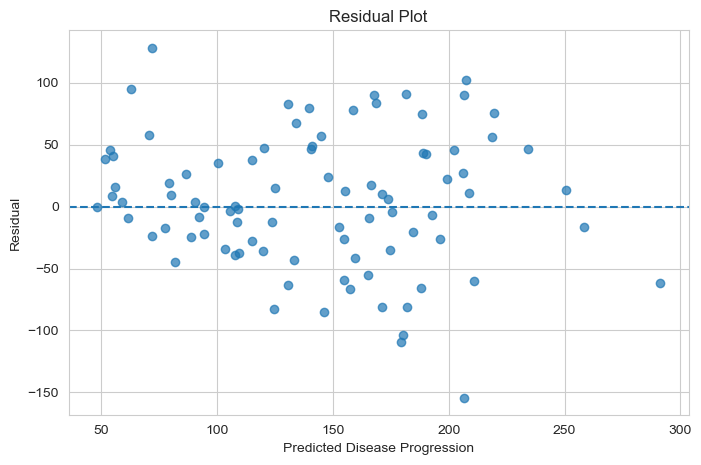

In [31]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Disease Progression"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residual Plot"
)

plt.show()